In [3]:
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import ICIW_Plots
import numpy as np
import torch

plt.style.use(["ICIWstyle", "ICIWlatex"])

In [4]:
# run_id = "ia4lixt7" # with the bug in the step function
run_id = "jkwy4zpw"
name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
model = RTDModule.load_from_checkpoint(ckpt_path)
# model.net.conv_layers[0].set_to_direct_response()

E1 = model.net.E[0].numpy()
E4 = model.net.E[1].numpy()
t1 = model.net.conv_layers[0].t_kernel.detach().numpy()
t4 = model.net.conv_layers[1].t_kernel.detach().numpy()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb:   1 of 1 files downloaded.  


In [5]:
print(I1 := np.trapz(E1, t1))
print(I4 := np.trapz(E4, t4))
print(I1 * I4)

0.9974046
0.93354404
0.9311211


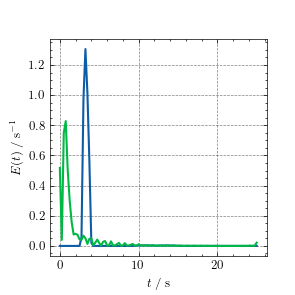

In [6]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \unit{\second}$",
    ylabel=r"$E(t)\;/\;\unit{\per\second}$",
)
ax.plot(t1, E1, label="E1")
ax.plot(t4, E4, label="E4")

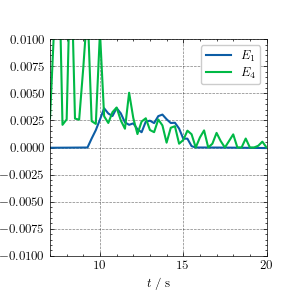

In [7]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \unit{\second}$",
    ylabel=r"$E(t)\;/\;\unit{\per\second}$",
    xlim=(7, 20),
    ylim=(-0.01, 0.01),
)
ax.plot(t1, E1, label="$E_1$")
ax.plot(t4, E4, label="$E_4$")
ax.legend()

## Compare with the data

(1, 1, 121)


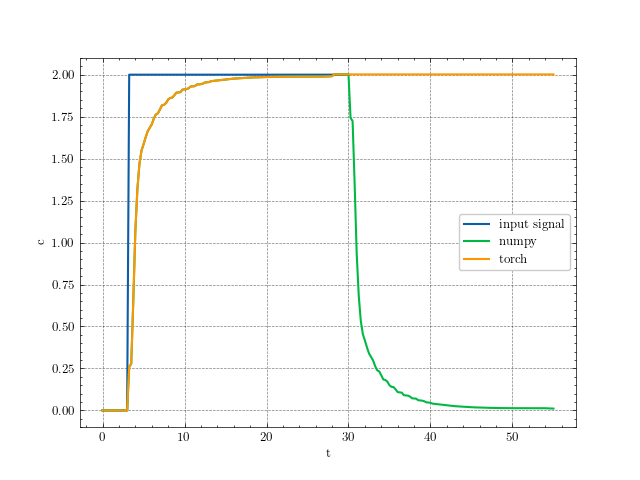

In [8]:
t = np.linspace(0, 30, 30 * 4 + 1)
t_out = np.linspace(0, 55, 55 * 4 + 1)

c_0 = np.zeros_like(t)
c_0[t > 3] = 2
print(c_0[None, None, :].shape)

c = np.convolve(E4, c_0) * 0.25
c_other = model.net.conv_layers[1](
    torch.tensor(c_0[None, None, :], dtype=torch.float),
    torch.tensor(t[None, :], dtype=torch.float),
)

plt.plot(t, c_0, label="input signal")
plt.plot(t_out, c, label="numpy")
plt.plot(t_out, c_other[0].detach().numpy().flatten(), label="torch")
plt.xlabel("t")
plt.ylabel("c")
plt.legend()